In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [27]:
df = pd.read_csv("../reports/partner_ops_train_vector.csv")
df.head()


,partner_id,total_30d,installs_30d,declines_30d,median_response_min_30d,total_60d,installs_60d,declines_60d,median_response_min_60d,total_365d,installs_365d,declines_365d,median_response_min_365d,se_30d,decline_rate_30d,se_60d,decline_rate_60d,se_365d,decline_rate_365d,total_decisions,median_response_min,nmbr_active_leads,long_held_leads_24h,resolved_leads,queue_velocity,expected_daily_slots,active_days,has_shock,shock_types,se_delta_30_60,decline_rate_delta_30_60,response_delta_30_60,se_delta_30_365,decline_rate_delta_30_365,response_delta_30_365
0,281749854622201,54,23,8,0.0,118,48,13,0.0,519,127,177,1.0,0.425926,0.148148,0.406780,0.110169,0.244701,0.341040,519,1.0,286,285,373,0.5660,NaN,NaN,0.0,NaN,0.019146,0.037979,0.0,0.181225,-0.192892,-1.0
1,274877924947,0,0,0,NaN,0,0,0,NaN,15,0,7,3067.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.466667,15,3067.0,148,148,23,0.1345,NaN,NaN,0.0,NaN,0.000000,0.000000,0.0,0.000000,-0.466667,-3067.0
2,281749854737624,10,6,2,956.5,22,8,4,1.0,472,143,146,4.0,0.600000,0.200000,0.363636,0.181818,0.302966,0.309322,472,4.0,265,262,322,0.5486,NaN,NaN,0.0,NaN,0.236364,0.018182,955.5,0.297034,-0.109322,952.5
3,281749854659597,0,0,0,NaN,1,0,0,7376.0,23,0,22,20046.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.956522,23,20046.0,116,116,40,0.2564,NaN,NaN,0.0,NaN,0.000000,0.000000,-7376.0,0.000000,-0.956522,-20046.0
4,274877942232,0,0,0,NaN,0,0,0,NaN,102,33,24,1.0,0.000000,0.000000,0.000000,0.000000,0.323529,0.235294,102,1.0,107,107,69,0.3920,NaN,NaN,0.0,NaN,0.000000,0.000000,0.0,-0.323529,-0.235294,-1.0


In [28]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (1475, 35)
<class 'pandas.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   partner_id                 1475 non-null   int64  
 1   total_30d                  1475 non-null   int64  
 2   installs_30d               1475 non-null   int64  
 3   declines_30d               1475 non-null   int64  
 4   median_response_min_30d    1070 non-null   float64
 5   total_60d                  1475 non-null   int64  
 6   installs_60d               1475 non-null   int64  
 7   declines_60d               1475 non-null   int64  
 8   median_response_min_60d    1225 non-null   float64
 9   total_365d                 1475 non-null   int64  
 10  installs_365d              1475 non-null   int64  
 11  declines_365d              1475 non-null   int64  
 12  median_response_min_365d   1475 non-null   float64
 13  se_30d                     1475 non-null 

,partner_id,total_30d,installs_30d,declines_30d,median_response_min_30d,total_60d,installs_60d,declines_60d,median_response_min_60d,total_365d,installs_365d,declines_365d,median_response_min_365d,se_30d,decline_rate_30d,se_60d,decline_rate_60d,se_365d,decline_rate_365d,total_decisions,median_response_min,nmbr_active_leads,long_held_leads_24h,resolved_leads,queue_velocity,expected_daily_slots,active_days,has_shock,se_delta_30_60,decline_rate_delta_30_60,response_delta_30_60,se_delta_30_365,decline_rate_delta_30_365,response_delta_30_365
count,1.475000e+03,1475.000000,1475.000000,1475.000000,1070.000000,1475.000000,1475.000000,1475.000000,1225.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,0.0,0.0,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000
mean,2.481637e+14,33.903051,11.387119,9.133559,561.791589,71.825085,23.410169,20.413559,636.430204,489.218983,104.527458,242.280678,590.248814,0.226925,0.197660,0.228518,0.257300,0.218868,0.451183,489.218983,590.248814,309.313898,305.985763,407.917288,0.519924,NaN,NaN,0.042034,-0.001592,-0.059640,-121.023729,0.008057,-0.253523,-182.711864
std,9.127586e+13,40.939187,15.410704,18.080528,2230.335886,81.276197,29.887996,36.049075,2525.650651,518.968065,118.157059,338.569326,1963.069040,0.246508,0.270120,0.226130,0.294571,0.163978,0.273247,518.968065,1963.069040,317.605384,314.140635,467.490011,0.186736,NaN,NaN,0.200735,0.105996,0.210031,2211.182808,0.188563,0.298427,2667.936773
min,2.748779e+11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,-1.000000,-1.000000,-29106.000000,-1.000000,-1.000000,-31774.000000
25%,2.817499e+14,0.000000,0.000000,0.000000,0.500000,3.000000,0.000000,0.000000,1.000000,112.000000,15.000000,25.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.092379,0.220032,112.000000,2.000000,87.500000,85.000000,79.500000,0.417800,NaN,NaN,0.000000,-0.019974,-0.059395,-1.000000,-0.086766,-0.415903,-135.250000
50%,2.817499e+14,18.000000,3.000000,1.000000,2.000000,45.000000,8.000000,6.000000,2.500000,336.000000,64.000000,116.000000,33.000000,0.153846,0.051724,0.187500,0.142857,0.192118,0.447924,336.000000,33.000000,205.000000,204.000000,261.000000,0.545200,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,-0.197954,-6.000000
75%,2.817499e+14,55.000000,20.000000,10.000000,68.375000,114.000000,42.500000,25.000000,85.000000,680.000000,151.000000,319.500000,269.000000,0.415485,0.333333,0.400000,0.420227,0.324618,0.659624,680.000000,269.000000,431.000000,426.000000,555.500000,0.643700,NaN,NaN,0.000000,0.023389,0.005160,1.000000,0.120948,-0.042095,0.000000
max,2.817499e+14,337.000000,86.000000,156.000000,27738.000000,606.000000,164.000000,305.000000,29106.000000,4147.000000,832.000000,3015.000000,31774.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4147.000000,31774.000000,3104.000000,3055.000000,3942.000000,1.000000,NaN,NaN,1.000000,0.944444,0.460317,20361.000000,0.929907,0.618461,27737.000000


In [29]:
df["install_rate"] = df["installs_30d"] / df["total_decisions"]
df["decline_rate_calc"] = df["declines_30d"] / df["total_decisions"]

df["lead_resolution_rate"] = df["resolved_leads"] / df["nmbr_active_leads"]

df["hold_ratio"] = df["long_held_leads_24h"] / df["nmbr_active_leads"]

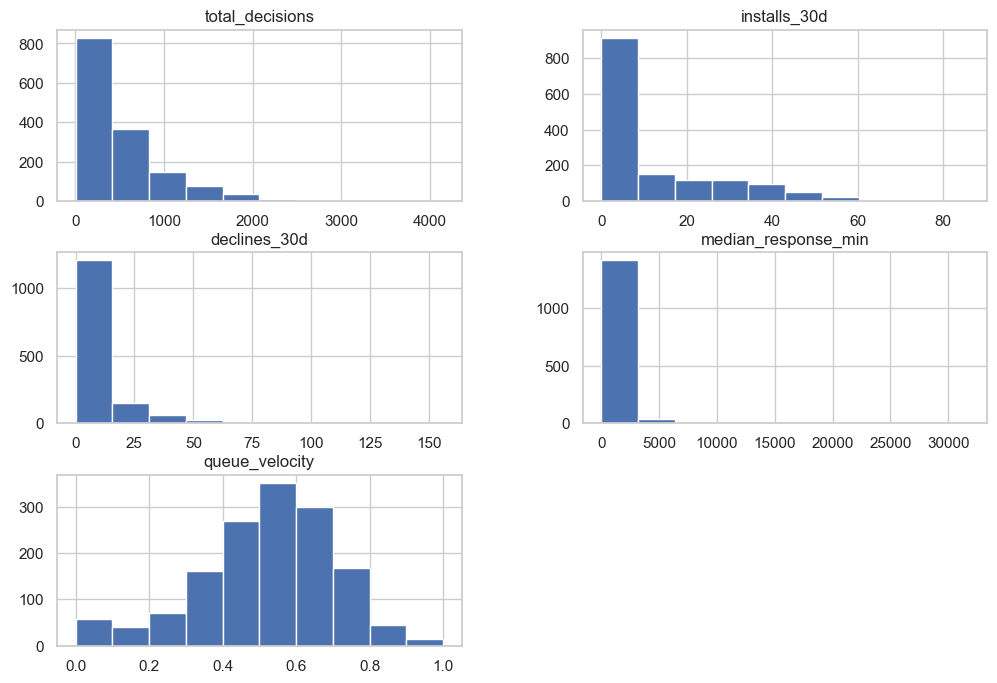

In [30]:
cols = [
    "total_decisions",
    "installs_30d",
    "declines_30d",
    "median_response_min",
    "queue_velocity",
]

df[cols].hist(figsize=(12,8))
plt.show()

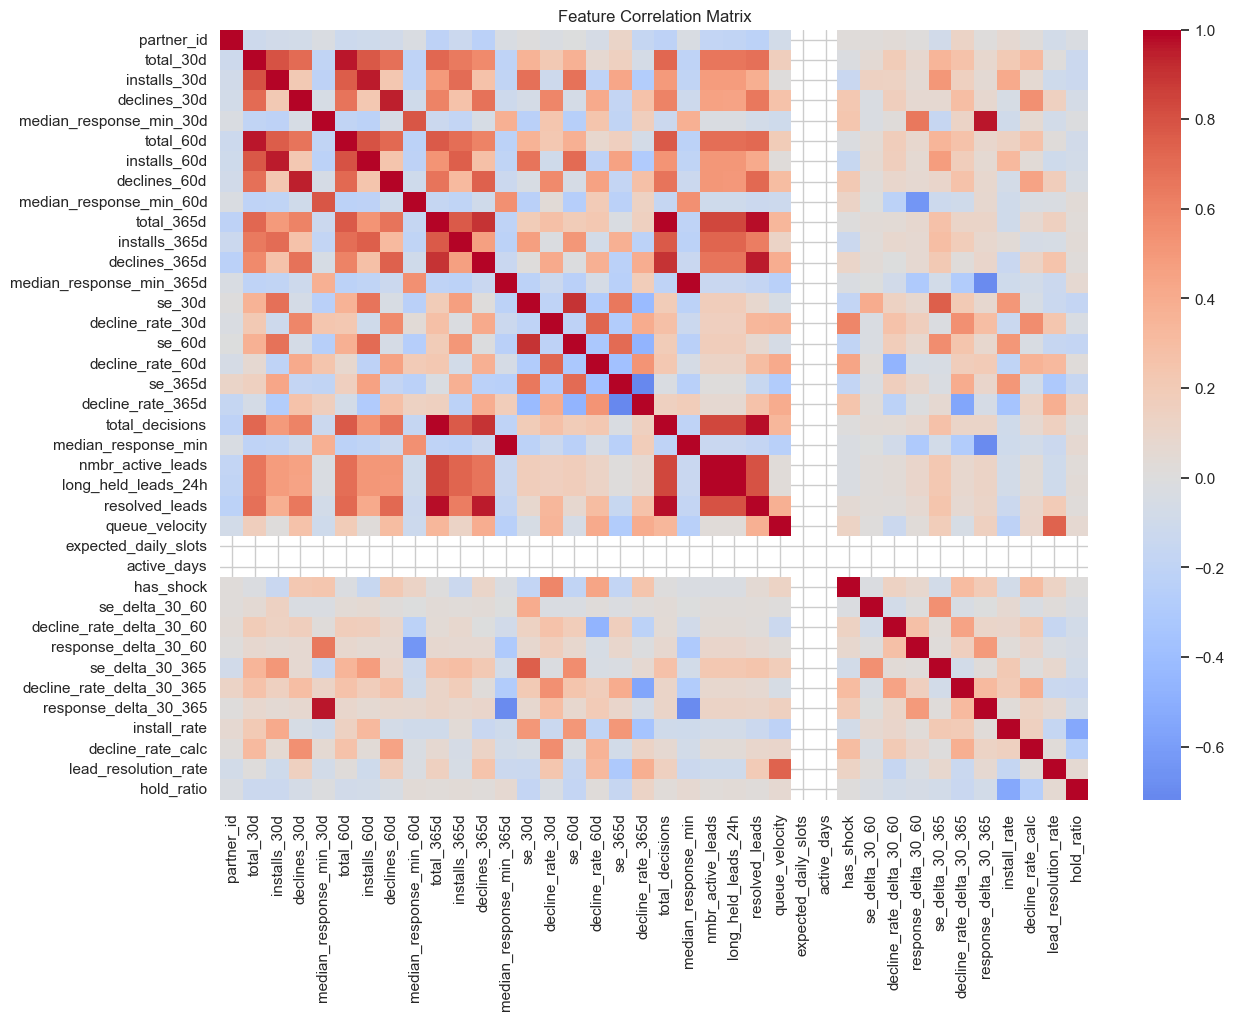

In [31]:
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

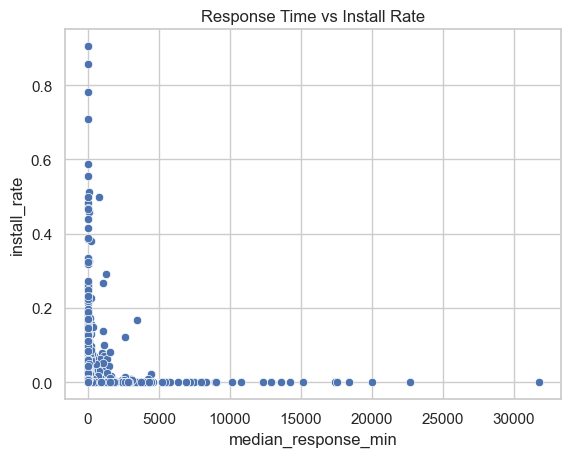

In [32]:
sns.scatterplot(
    data=df,
    x="median_response_min",
    y="install_rate"
)

plt.title("Response Time vs Install Rate")
plt.show()

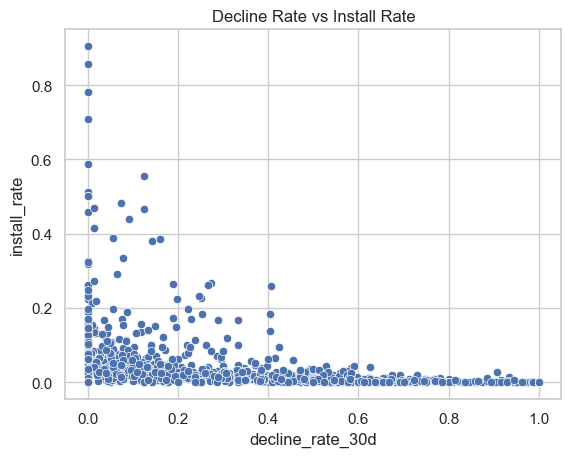

In [33]:
sns.scatterplot(
    data=df,
    x="decline_rate_30d",
    y="install_rate"
)

plt.title("Decline Rate vs Install Rate")
plt.show()

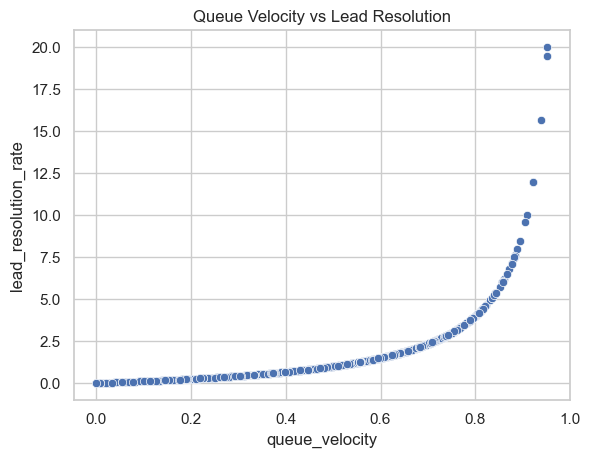

In [34]:
sns.scatterplot(
    data=df,
    x="queue_velocity",
    y="lead_resolution_rate"
)

plt.title("Queue Velocity vs Lead Resolution")
plt.show()

In [35]:
scores = [
    "capacity_score",
    "reliability_score",
    "infrastructure_score",
    "operational_score"
]

df[scores].plot(kind="box", figsize=(8,5))

plt.title("Partner Score Distribution")
plt.show()

KeyError: "None of [Index(['capacity_score', 'reliability_score', 'infrastructure_score',\n       'operational_score'],\n      dtype='str')] are in the [columns]"

In [ ]:
df.sort_values("install_rate", ascending=False)[
    ["partner_id","install_rate","decline_rate_30d","median_response_min"]
].head(10)

,partner_id,install_rate,decline_rate_30d,median_response_min
783,281749854762428,1.000000,0.0,0.0
635,281749854813655,1.000000,0.0,768.0
172,281749854627301,1.000000,0.0,3.0
1011,281749854632219,1.000000,0.0,0.0
83,281749855002772,1.000000,0.0,0.0
1098,281749854770627,1.000000,0.0,10.0
1006,281749854699257,1.000000,0.0,3.0
641,281749854631012,1.000000,0.0,0.0
596,281749854658145,0.967742,0.0,0.0
284,281749854771996,0.951220,0.0,1801.0


In [ ]:
df.sort_values("decline_rate_30d", ascending=False)[
    ["partner_id","install_rate","decline_rate_30d","median_response_min"]
].head(10)

,partner_id,install_rate,decline_rate_30d,median_response_min
210,281749854699617,0.0,1.0,5938.0
108,281749854666010,0.0,1.0,1004.5
403,281749854629786,0.0,1.0,9330.0
950,281749854691346,0.0,1.0,2743.0
1023,281749854755693,0.0,1.0,116.0
287,281749854698045,0.0,1.0,1.0
684,281749854661311,0.0,1.0,33.0
937,281749854664669,0.0,1.0,0.0
891,281749854797416,0.0,1.0,0.0
606,281749854704612,0.0,1.0,0.5


In [ ]:
from scipy.stats import zscore

numeric = df.select_dtypes(include=np.number)

z_scores = np.abs(zscore(numeric))

outliers = df[(z_scores > 3).any(axis=1)]

outliers

,partner_id,total_decisions,installs_30d,declines_30d,median_response_min,mean_response_min,se_30d,decline_rate_30d,nmbr_active_leads,long_held_leads_24h,resolved_leads,queue_velocity,expected_daily_slots,active_days,has_shock,shock_types,gate_nonresponder,gate_capacity,gate_shock,gate_blocked,capacity_score,reliability_score,infrastructure_score,operational_score,install_rate,decline_rate_calc,lead_resolution_rate,hold_ratio
11,281749854643296,66,0,60,0.0,66.772727,0.000000,0.909091,12.0,10.0,46.0,0.7931,NaN,NaN,1.0,decline_spike,1,0,1,1,0.39655,NaN,0.0,0.000000,0.000000,0.909091,3.833333,0.833333
12,281749854659870,154,19,90,217.0,1063.694805,0.123377,0.584416,110.0,91.0,90.0,0.4500,NaN,NaN,0.0,NaN,0,0,0,0,0.22500,NaN,1.0,0.612500,0.123377,0.584416,0.818182,0.827273
14,281749854709560,12,1,1,22.0,450.583333,0.083333,0.083333,2.0,2.0,10.0,0.8333,NaN,NaN,0.0,NaN,0,0,0,0,0.81665,NaN,1.0,0.908325,0.083333,0.083333,5.000000,1.000000
15,281749854653887,220,60,135,30.0,1089.840909,0.272727,0.613636,93.0,77.0,135.0,0.5921,NaN,NaN,0.0,NaN,0,0,0,0,0.29605,NaN,1.0,0.648025,0.272727,0.613636,1.451613,0.827957
25,281749854725931,6,0,6,5321.5,4883.166667,0.000000,1.000000,0.0,0.0,3.0,1.0000,NaN,NaN,0.0,NaN,0,0,0,0,1.00000,NaN,1.0,1.000000,0.000000,1.000000,inf,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,281749854813657,10,1,3,20.5,765.800000,0.100000,0.300000,1.0,1.0,7.0,0.8750,NaN,NaN,0.0,NaN,0,0,0,0,0.88750,NaN,1.0,0.943750,0.100000,0.300000,7.000000,1.000000
1083,281749854680495,11,2,0,1.0,2707.000000,0.181818,0.000000,1.0,1.0,3.0,0.7500,NaN,NaN,0.0,NaN,0,0,0,0,0.82500,NaN,1.0,0.912500,0.181818,0.000000,3.000000,1.000000
1092,274877917842,137,31,52,1.0,862.708029,0.226277,0.379562,151.0,128.0,75.0,0.3319,NaN,NaN,0.0,NaN,0,0,0,0,0.16595,NaN,1.0,0.582975,0.226277,0.379562,0.496689,0.847682
1102,281749854690137,139,28,67,995.0,1974.848921,0.201439,0.482014,144.0,117.0,67.0,0.3175,NaN,NaN,0.0,NaN,0,0,0,0,0.15875,NaN,1.0,0.579375,0.201439,0.482014,0.465278,0.812500


In [ ]:
df["partner_health"] = (
    df["install_rate"] * 0.5
    + (1 - df["decline_rate_30d"]) * 0.3
    + (1 / (1 + df["median_response_min"])) * 0.2
)

df.sort_values("partner_health", ascending=False).head()

,partner_id,total_decisions,installs_30d,declines_30d,median_response_min,mean_response_min,se_30d,decline_rate_30d,nmbr_active_leads,long_held_leads_24h,resolved_leads,queue_velocity,expected_daily_slots,active_days,has_shock,shock_types,gate_nonresponder,gate_capacity,gate_shock,gate_blocked,capacity_score,reliability_score,infrastructure_score,operational_score,install_rate,decline_rate_calc,lead_resolution_rate,hold_ratio,partner_health
83,281749855002772,7,7,0,0.0,5.000000,1.000000,0.0,13.0,6.0,0.0,0.0000,NaN,NaN,0.0,NaN,0,0,0,0,0.0000,NaN,1.0,0.50000,1.000000,0.0,0.000000,0.461538,1.000000
783,281749854762428,4,4,0,0.0,0.250000,1.000000,0.0,4.0,4.0,0.0,0.0000,NaN,NaN,0.0,NaN,0,0,0,0,0.3000,NaN,1.0,0.65000,1.000000,0.0,0.000000,1.000000,1.000000
641,281749854631012,1,1,0,0.0,0.000000,1.000000,0.0,1.0,1.0,0.0,0.0000,NaN,NaN,0.0,NaN,0,0,0,0,0.4500,NaN,1.0,0.72500,1.000000,0.0,0.000000,1.000000,1.000000
1011,281749854632219,2,2,0,0.0,0.000000,1.000000,0.0,3.0,3.0,0.0,0.0000,NaN,NaN,0.0,NaN,0,0,0,0,0.3500,NaN,1.0,0.67500,1.000000,0.0,0.000000,1.000000,1.000000
596,281749854658145,31,30,0,0.0,21.064516,0.967742,0.0,23.0,21.0,3.0,0.1154,NaN,NaN,0.0,NaN,0,0,0,0,0.0577,NaN,1.0,0.52885,0.967742,0.0,0.130435,0.913043,0.983871


In [ ]:
df[
[
"partner_id",
"install_rate",
"decline_rate_30d",
"median_response_min",
"queue_velocity",
"partner_health"
]
].sort_values("partner_health", ascending=False)

,partner_id,install_rate,decline_rate_30d,median_response_min,queue_velocity,partner_health
83,281749855002772,1.000000,0.0,0.0,0.0000,1.000000
783,281749854762428,1.000000,0.0,0.0,0.0000,1.000000
641,281749854631012,1.000000,0.0,0.0,0.0000,1.000000
1011,281749854632219,1.000000,0.0,0.0,0.0000,1.000000
596,281749854658145,0.967742,0.0,0.0,0.1154,0.983871
...,...,...,...,...,...,...
25,281749854725931,0.000000,1.0,5321.5,1.0000,0.000038
210,281749854699617,0.000000,1.0,5938.0,0.1250,0.000034
501,281749854699647,0.000000,1.0,9117.0,0.2250,0.000022
403,281749854629786,0.000000,1.0,9330.0,0.2500,0.000021
